# PolyNomial Learning Rate Scheduler Visualization

This notebook visualizes the learning rate schedule before starting training using the PolyNomialLRScheduler.
The scheduler implements a polynomial decay schedule with optional warmup phase.

In [50]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.optim.lr_scheduler import LambdaLR

## Hyperparameters

In [51]:
# Learning Rate Scheduler Configuration
hyperparameters = {
    # Base learning rate (peak learning rate after warmup)
    'lr': 4e-4,
    
    # Minimum learning rate after polynomial decay
    'lr_end': 1e-5,
    
    # Initial learning rate for warmup phase
    'warmup_init_lr': 1e-7,
    
    # Number of warmup steps (linear increase from warmup_init_lr to lr)
    'warmup_steps': 2000,
    
    # Total number of training steps
    'total_steps': 200000,
    
    # Power of the polynomial decay (1.0 = linear, 2.0 = quadratic, etc.)
    'power': 1.0,
}

# Extract hyperparameters for easier access
lr = hyperparameters['lr']
lr_end = hyperparameters['lr_end']
warmup_init_lr = hyperparameters['warmup_init_lr']
warmup_steps = hyperparameters['warmup_steps']
total_steps = hyperparameters['total_steps']
power = hyperparameters['power']

print("Learning Rate Scheduler Configuration:")
print(f"  Base LR: {lr}")
print(f"  Final LR: {lr_end}")
print(f"  Warmup Initial LR: {warmup_init_lr}")
print(f"  Warmup Steps: {warmup_steps}")
print(f"  Total Steps: {total_steps}")
print(f"  Polynomial Power: {power}")

Learning Rate Scheduler Configuration:
  Base LR: 0.0004
  Final LR: 1e-05
  Warmup Initial LR: 1e-07
  Warmup Steps: 2000
  Total Steps: 200000
  Polynomial Power: 1.0


## Polynomial LR Schedule Implementation

In [52]:
def polynomial_lr_schedule(step, total_steps, warmup_steps, warmup_init_lr, lr, lr_end, power):
    """
    Compute the learning rate multiplier at a given training step.
    
    Schedule:
    1. Warmup phase (0 to warmup_steps): Linear increase from warmup_init_lr to lr
    2. Decay phase (warmup_steps to total_steps): Polynomial decay from lr to lr_end
    3. Final phase (> total_steps): Constant at lr_end
    """
    if step < warmup_steps:
        # Linear warmup
        return warmup_init_lr + (lr - warmup_init_lr) * step / warmup_steps
    elif step > total_steps:
        # After total_steps, use minimum learning rate
        return lr_end
    else:
        # Polynomial decay phase
        return (
            lr_end
            + (lr - lr_end)
            * (1 - (step - warmup_steps) / (total_steps - warmup_steps))
            ** power
        )


class PolyNomialLRScheduler(LambdaLR):
    """Polynomial decay learning rate scheduler with warmup."""
    
    def __init__(
        self,
        optimizer,
        total_steps: int = 1000,
        warmup_steps: int = 0,
        lr: float = 5e-4,
        lr_end: float = 1e-7,
        warmup_init_lr: float = 1e-7,
        power: float = 1.0,
    ):
        self.warmup_init_lr = warmup_init_lr
        self.warmup_steps = warmup_steps

        def lr_lambda(step):
            return (
                polynomial_lr_schedule(
                    step,
                    total_steps,
                    warmup_steps,
                    warmup_init_lr,
                    lr,
                    lr_end,
                    power,
                )
                / lr
            )

        super().__init__(optimizer, lr_lambda=lr_lambda)

## Initialize Scheduler and Calculate Learning Rates

In [53]:
# Create a dummy model and optimizer
dummy_model = torch.nn.Linear(10, 1)
optimizer = optim.Adam(dummy_model.parameters(), lr=lr)

# Initialize the scheduler
scheduler = PolyNomialLRScheduler(
    optimizer,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
    lr=lr,
    lr_end=lr_end,
    warmup_init_lr=warmup_init_lr,
    power=power,
)

# Collect learning rates across all training steps
learning_rates = []
steps = []

for step in range(total_steps + 1000):  # Include some steps beyond total_steps to see the final behavior
    step_lr = scheduler.get_last_lr()[0]
    learning_rates.append(step_lr)
    steps.append(step)

    # Step the scheduler
    if step < total_steps:
        scheduler.step()

peak_lr = max(learning_rates)

print(f"Collected learning rates for {len(learning_rates)} steps")
print(f"Initial LR: {learning_rates[0]:.2e}")
print(f"Peak LR (at end of warmup): {peak_lr:.2e}")
print(f"Final LR: {learning_rates[-1]:.2e}")

Collected learning rates for 201000 steps
Initial LR: 1.00e-07
Peak LR (at end of warmup): 4.00e-04
Final LR: 1.00e-05


## Visualize Learning Rate Schedule

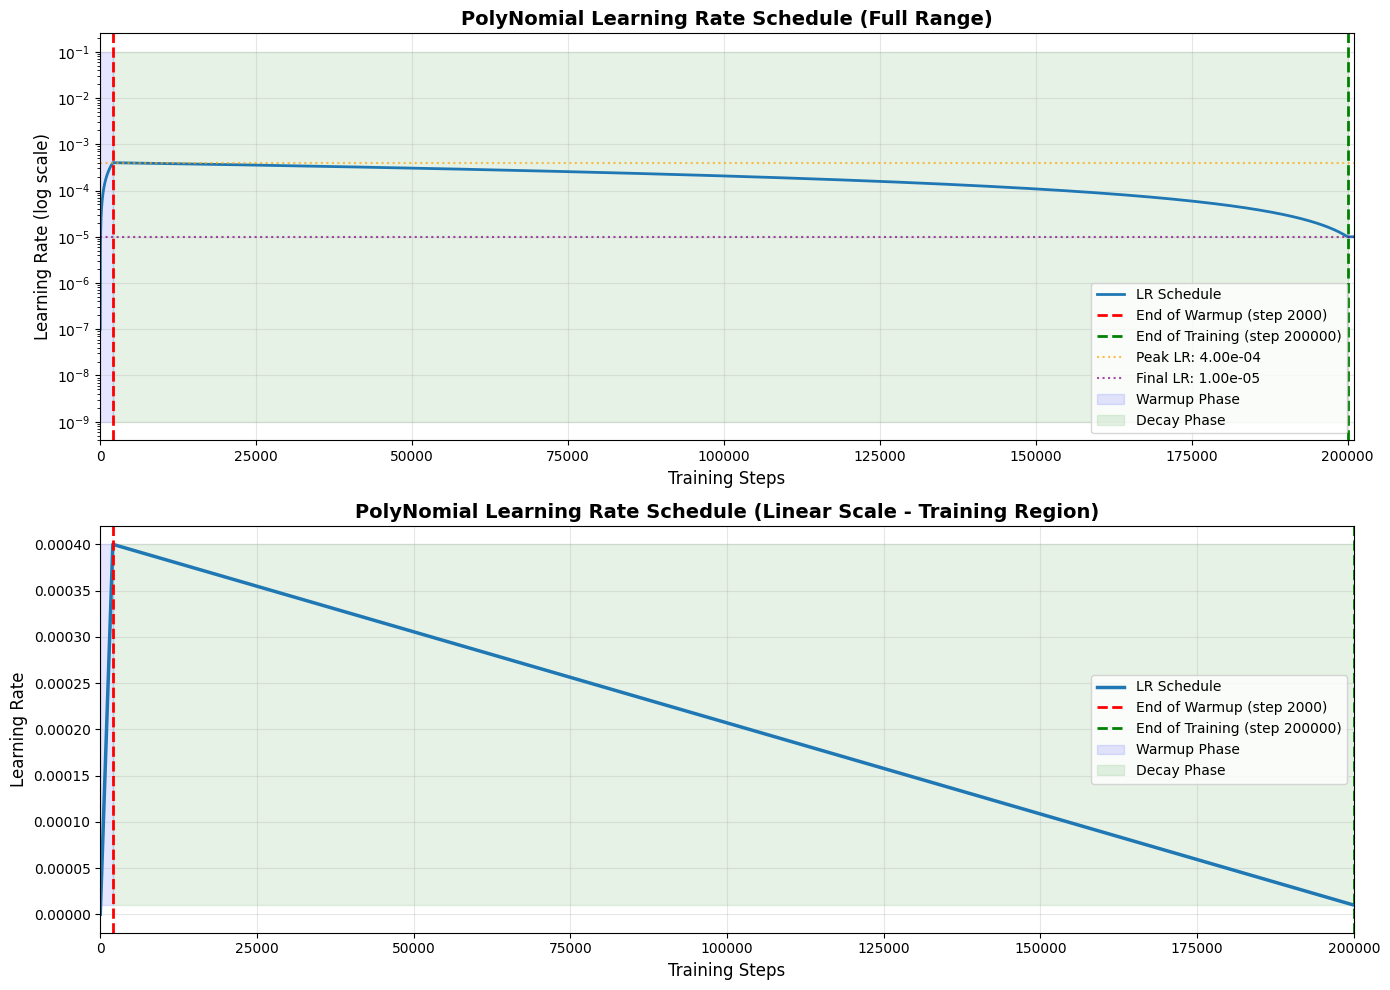

Plot saved to: /storage/brno2/home/soldatmat/documents/terpene_synthases/dplm/plot/lr_schedule.png


In [54]:
# Create a comprehensive visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Full learning rate schedule (log scale)
ax1 = axes[0]
ax1.semilogy(steps, learning_rates, linewidth=2, label='LR Schedule')
ax1.axvline(x=warmup_steps, color='red', linestyle='--', linewidth=2, label=f'End of Warmup (step {warmup_steps})')
ax1.axvline(x=total_steps, color='green', linestyle='--', linewidth=2, label=f'End of Training (step {total_steps})')
ax1.axhline(y=peak_lr, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Peak LR: {peak_lr:.2e}')
ax1.axhline(y=lr_end, color='purple', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Final LR: {lr_end:.2e}')
ax1.fill_between([0, warmup_steps], 1e-9, 1e-1, alpha=0.1, color='blue', label='Warmup Phase')
ax1.fill_between([warmup_steps, total_steps], 1e-9, 1e-1, alpha=0.1, color='green', label='Decay Phase')
ax1.set_xlabel('Training Steps', fontsize=12)
ax1.set_ylabel('Learning Rate (log scale)', fontsize=12)
ax1.set_title('PolyNomial Learning Rate Schedule (Full Range)', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, total_steps + 1000)

# Plot 2: Zoomed in on warmup and decay phases
ax2 = axes[1]
ax2.plot(steps[:total_steps], learning_rates[:total_steps], linewidth=2.5, label='LR Schedule')
ax2.axvline(x=warmup_steps, color='red', linestyle='--', linewidth=2, label=f'End of Warmup (step {warmup_steps})')
ax2.axvline(x=total_steps, color='green', linestyle='--', linewidth=2, label=f'End of Training (step {total_steps})')
ax2.fill_between([0, warmup_steps], lr_end, lr, alpha=0.1, color='blue', label='Warmup Phase')
ax2.fill_between([warmup_steps, total_steps], lr_end, lr, alpha=0.1, color='green', label='Decay Phase')
ax2.set_xlabel('Training Steps', fontsize=12)
ax2.set_ylabel('Learning Rate', fontsize=12)
ax2.set_title('PolyNomial Learning Rate Schedule (Linear Scale - Training Region)', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, total_steps)

plt.tight_layout()
# plt.savefig('/storage/brno2/home/soldatmat/documents/terpene_synthases/dplm/plot/lr_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: /storage/brno2/home/soldatmat/documents/terpene_synthases/dplm/plot/lr_schedule.png")